# ドイチュのアルゴリズム（Deutsch's Algorithm）
1bitの情報(0 or 1)が入力されて0か1を返す関数は4パターン考えられる。
<div style="display: flex; gap: 20px;">

| $a$ | $f_1(a)$ |
| :---: | :---: |
| $0$ | $0$ |
| $1$ | $0$ |

| $a$ | $f_2(a)$ |
| :---: | :---: |
| $0$ | $0$ |
| $1$ | $1$ |

| $a$ | $f_3(a)$ |
| :---: | :---: |
| $0$ | $1$ |
| $1$ | $0$ |

| $a$ | $f_4(a)$ |
| :---: | :---: |
| $0$ | $1$ |
| $1$ | $1$ |

</div>

$f_1,f_4$のことをconstant、$f_2,f_3$のことをbalancedとよぶ。  
ドイチュのアルゴリズムでは与えられた関数$f$がconstantなのかbalancedなのかを判定することができる。

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

まずはドイチュのアルゴリズムでconstantかbalancedかを判定される関数$f$を作る。  
関数の引数として1,2,3,4を選択することができ、引数に対応して$f_1,f_2,f_3,f_4$を得る。

In [4]:
def deutsch_function(case: int):
    if case not in [1,2,3,4]:
        raise ValueError("`case` must be 1,2,3,or4.")

    f = QuantumCircuit(2)
    if case in [2,3]:
        f.cx(0,1)
    if case in [3,4]:
        f.x(1)
    return f

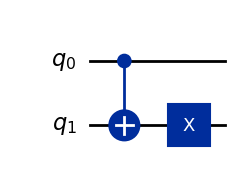

In [5]:
display(deutsch_function(3).draw(output = "mpl"))

In [8]:
# 一般のnに対して関数を定義することでドイチュ・ジョサのアルゴリズムに適用可能
def compile_circuit(function: QuantumCircuit):
    n = function.num_qubits - 1
    qc = QuantumCircuit(n+1, n) #n qubitに加えて1 qubitのancilla qubitを用意

    qc.x(n)
    qc.h(range(n+1))
    qc.barrier()

    qc.compose(function, inplace = True)
    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))

    return qc

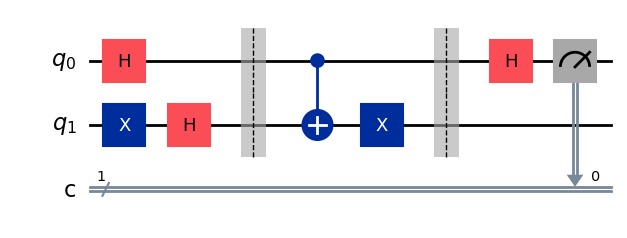

In [9]:
display(compile_circuit(deutsch_function(3)).draw(output = "mpl"))

In [10]:
def deutsch_algorithm(function: QuantumCircuit):
    qc = compile_circuit(function)
    result = AerSimulator().run(qc, shots = 1, memory = True).result()
    measurements = result.get_memory()
    if measurements[0] == "0":
        return "constant"
    return "balanced"

In [15]:
f = deutsch_function(3)
display(deutsch_algorithm(f))

'balanced'